# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Black hole spin (`a`)**  
- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
include("../src/main.jl")
println("Available threads: ", nthreads())
#REMEMBER TO CHANGE MODEL = "ANALYTIC" in set_globals.jl

Available threads: 1


### Autodiff Image and Derivative Calculation

This cell computes the **image intensity** and its **derivatives** with respect to the black hole spin (`a`) and observer inclination (`θ`) using the **AutodiffGeoTrajEulerMethod**.  

- **Pre-allocation**: Arrays are created to store the intensity (`I_arr`) and derivatives (`dI_da_arr`, `dI_dθo_arr`) for each pixel.  
- **Threaded computation**: Trajectories are pre-allocated per thread to enable parallel execution.  
- **Autodiff integration**: For each pixel `(i, j)`, the method computes:  
  - `intensity_out` → final pixel intensity  
  - `dI_da_out` → derivative with respect to spin  
  - `dI_dθo_out` → derivative with respect to inclination  

The resulting **intensity array (`I_arr`) will serve as the ground truth** for the **conjugate gradient parameter recovery** in subsequent cells.  

Progress is monitored across threads to track completion.


In [22]:
#Define the number of pixels for each image
const nx, ny = 40,40
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_da_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX = DY = 30
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, 7.778e3 * PC, L_unit)
const freq = 230e9
const ro = 1000.0
const fovx = fovy = DX / ro
const nmaxstep = 15000
const bhspin = 0.9
const Rout = 1000.0
const Rstop = 10000.0
const th_test = 17.0
const phi = 0.0

#delete both afterwards
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Pre-allocate trajectory arrays for each thread
const num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, num_threads)
for tid in 1:num_threads
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny

const percentage_old = Ref(0.0)

#Here we run the Autodiff method
Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_da_out = Ref{Float64}(0.0)

        AutoDiffGeoTrajEulerMethod_GRMHD!(thread_trajs[tid], dI_dθo_out, intensity_out, dI_da_out,
            ro, th_test, phi, bhspin, nx, ny, nmaxstep, i, j, freq, fovx, fovy, Rout, Rstop)
            
        dI_da_arr[i + 1, j + 1] = dI_da_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]
        
        progress[Threads.threadid()] += 1
        if Threads.threadid() == 1
            total_progress = sum(progress)
            percentage = (total_progress / total) * 100
            
            if((percentage - percentage_old[]) > 5)
                println("Progress: $total_progress / $total ($(round(percentage, digits=2))%)")
                percentage_old[] = percentage
            end
        end
    end
end

total_progress = sum(progress)
percentage = (total_progress / total) * 100
println("Final Progress: $(total_progress/total) ($percentage%)")

Progress: 81 / 1600 (5.06%)
Progress: 162 / 1600 (10.12%)
Progress: 243 / 1600 (15.19%)
Progress: 324 / 1600 (20.25%)
Progress: 405 / 1600 (25.31%)
Progress: 486 / 1600 (30.38%)
Progress: 567 / 1600 (35.44%)
Progress: 648 / 1600 (40.5%)
Progress: 729 / 1600 (45.56%)
Progress: 810 / 1600 (50.62%)
Progress: 891 / 1600 (55.69%)
Progress: 971 / 1600 (60.69%)
Progress: 1052 / 1600 (65.75%)
Progress: 1133 / 1600 (70.81%)
Progress: 1214 / 1600 (75.88%)
Progress: 1295 / 1600 (80.94%)
Progress: 1376 / 1600 (86.0%)
Progress: 1457 / 1600 (91.06%)
Progress: 1538 / 1600 (96.12%)
Final Progress: 1.0 (100.0%)


In [23]:
using DelimitedFiles

writedlm("./dI_dth_GRMHD.txt", dI_dθo_arr)


In [24]:
# Finite Differenciating Theta
const h = 1e-7
const th_low = th_test - h
const th_high = th_test + h
const phi = 0.0
# Find camera in native coordinates
const Xcamera_low = MVec4(camera_position(ro, th_low, phi, bhspin, Rout))
const Xcamera_high = MVec4(camera_position(ro, th_high, phi, bhspin, Rout))
# Scales the intensity of each pixel by the real size of each pixel
const maxnstep = 15000
const Rh = 1 + sqrt(1. - bhspin * bhspin);

freq_unitless = freq * HPL/(ME * CL * CL);  # Convert frequency to unitless

In [25]:
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
Image_low = zeros(Float64, nx, ny)
for i in 0:(nx - 1)
    println("Processing row $i out of $(nx)")

    Threads.@threads for j in 0:(ny - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)
        nstep = get_pixel(traj, i, j, Xcamera_low, maxnstep, fovx, fovy, freq_unitless, nx, ny, bhspin, Rh, Rout, Rstop, 0.0, 0.0)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image_low, i + 1, j + 1, freq, bhspin)
    end
end
Image_low *= freq^3;

Utilizing 1 threads for geodesic calculation.
Processing row 0 out of 40
Processing row 1 out of 40
Processing row 2 out of 40
Processing row 3 out of 40
Processing row 4 out of 40
Processing row 5 out of 40
Processing row 6 out of 40
Processing row 7 out of 40
Processing row 8 out of 40
Processing row 9 out of 40
Processing row 10 out of 40
Processing row 11 out of 40
Processing row 12 out of 40
Processing row 13 out of 40
Processing row 14 out of 40
Processing row 15 out of 40
Processing row 16 out of 40
Processing row 17 out of 40
Processing row 18 out of 40
Processing row 19 out of 40
Processing row 20 out of 40
Processing row 21 out of 40
Processing row 22 out of 40
Processing row 23 out of 40
Processing row 24 out of 40
Processing row 25 out of 40
Processing row 26 out of 40
Processing row 27 out of 40
Processing row 28 out of 40
Processing row 29 out of 40
Processing row 30 out of 40
Processing row 31 out of 40
Processing row 32 out of 40
Processing row 33 out of 40
Processing r

In [26]:
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
Image_high = zeros(Float64, nx, ny)
for i in 0:(nx - 1)
    println("Processing row $i out of $(nx)")

    Threads.@threads for j in 0:(ny - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)
        nstep = get_pixel(traj, i, j, Xcamera_high, maxnstep, fovx, fovy, freq_unitless, nx, ny, bhspin, Rh, Rout, Rstop, 0.0, 0.0)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image_high, i + 1, j + 1, freq, bhspin)
    end
end
Image_high *= freq^3;

Utilizing 1 threads for geodesic calculation.
Processing row 0 out of 40
Processing row 1 out of 40
Processing row 2 out of 40
Processing row 3 out of 40
Processing row 4 out of 40
Processing row 5 out of 40
Processing row 6 out of 40
Processing row 7 out of 40
Processing row 8 out of 40
Processing row 9 out of 40
Processing row 10 out of 40
Processing row 11 out of 40
Processing row 12 out of 40
Processing row 13 out of 40
Processing row 14 out of 40
Processing row 15 out of 40
Processing row 16 out of 40
Processing row 17 out of 40
Processing row 18 out of 40
Processing row 19 out of 40
Processing row 20 out of 40
Processing row 21 out of 40
Processing row 22 out of 40
Processing row 23 out of 40
Processing row 24 out of 40
Processing row 25 out of 40
Processing row 26 out of 40
Processing row 27 out of 40
Processing row 28 out of 40
Processing row 29 out of 40
Processing row 30 out of 40
Processing row 31 out of 40
Processing row 32 out of 40
Processing row 33 out of 40
Processing r

In [27]:
dI_dθo_arr_FD = (Image_high - Image_low)/(2 *h)

40×40 Matrix{Float64}:
  3.41227e-11   3.76936e-10   7.3915e-10   …   1.56896e-9    1.26631e-9
  7.49619e-11   4.39306e-10   8.22097e-10      1.63225e-9    1.32645e-9
  1.19198e-10   5.04361e-10   9.06557e-10      1.69127e-9    1.3807e-9
  1.65996e-10   5.709e-10     9.91532e-10      1.73461e-9    1.41768e-9
  2.14185e-10   6.37806e-10   1.07572e-9       1.75902e-9    1.44537e-9
  2.6251e-10    7.03781e-10   1.1577e-9    …   1.76827e-9    1.46126e-9
  3.09838e-10   7.67306e-10   1.23623e-9       1.76367e-9    1.45921e-9
  3.5448e-10    8.26925e-10   1.30948e-9       1.74128e-9    1.44399e-9
  3.95055e-10   8.8111e-10    1.37606e-9       1.70282e-9    1.41487e-9
  4.29975e-10   9.28224e-10   1.43428e-9       1.64546e-9    1.37035e-9
  4.57592e-10   9.66381e-10   1.48238e-9   …   1.57583e-9    1.30635e-9
  4.7632e-10    9.94045e-10   1.51844e-9       1.48044e-9    1.23004e-9
  4.84705e-10   1.00959e-9    1.54069e-9       1.37308e-9    1.14013e-9
  ⋮                                       

In [28]:
using DelimitedFiles

writedlm("./dI_dth_FD.txt", dI_dθo_arr_FD)


Plotting the image and the derivatives with proper angular spacing

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/Vn16E/src/scenes.jl:264


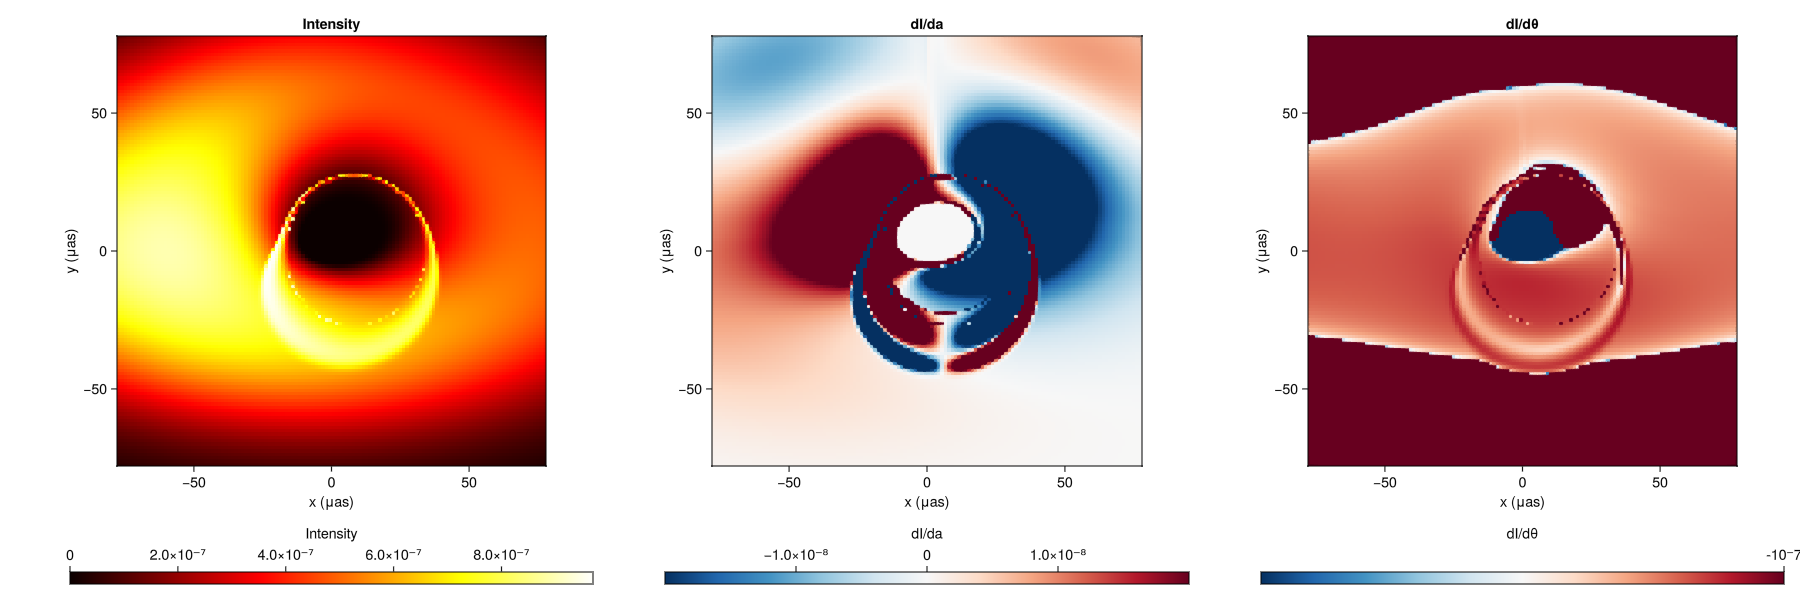

In [11]:
using GLMakie

# Calculate field of view limits
d_kpc = 7.78
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas

# Create coordinate arrays for proper mapping
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# Create figure with proper layout
fig = Figure(resolution=(1800, 600))

# Plot 1: Intensity
ax1 = Axis(fig[1, 1], 
    title="Intensity",
    xlabel="x (μas)",
    ylabel="y (μas)",
    aspect=DataAspect())
    
hm1 = heatmap!(ax1, x_coords, y_coords, I_arr, 
    colormap=:hot)
    
# Colorbar for intensity
Colorbar(fig[2, 1], hm1, 
    label="Intensity",
    vertical=false)

# Plot 2: dI/da  
ax2 = Axis(fig[1, 2], 
    title="dI/da",
    xlabel="x (μas)",
    ylabel="y (μas)",
    aspect=DataAspect())

hm2 = heatmap!(ax2, x_coords, y_coords, dI_da_arr, 
    colormap=Reverse(:RdBu),
    colorrange=(-2e-8, 2e-8))


# Colorbar for dI/da
Colorbar(fig[2, 2], hm2, 
    label="dI/da",
    vertical=false)

# Plot 3: dI/dθ
ax3 = Axis(fig[1, 3], 
    title="dI/dθ",
    xlabel="x (μas)",
    ylabel="y (μas)",
    aspect=DataAspect())


# Transform data for symlog-like visualization
dI_dθo_transformed = sign.(dI_dθo_arr) .* log10.(abs.(dI_dθo_arr) .+ 1e-12)  # Add small value to avoid log(0)

hm3 = heatmap!(ax3, x_coords, y_coords, dI_dθo_transformed, 
    colormap=Reverse(:RdBu),
    colorrange=(-12, -7)) 

Colorbar(fig[2, 3], hm3, 
    label="dI/dθ",
    vertical=false,
    ticks=[-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7],
    tickformat=values -> [v == 0 ? "0" : v > 0 ? "10⁻$(Int(v))" : "-10⁻$(Int(-v))" for v in values])


fig

### Parameter Recovery via Conjugate Gradient

In this cell, we use the **conjugate gradient algorithm** to recover the **ground truth black hole spin (`a`)** and **observer inclination (`θ`)** from the computed intensity map (`I_arr`).  

- `initial_spin_guess` and `initial_th_guess` provide the starting point for the optimization.  
- `true_conjugate_gradient_optimization` iteratively adjusts the parameters to minimize the difference between the **ground truth intensity** and the intensity predicted by the current parameter guess.  
- The outputs are:  
  - `ths` → recovered inclination values over iterations  
  - `as` → recovered spin values over iterations  
  - `err` → error at each iteration  
  - `steps` → number of iterations taken  

This procedure demonstrates **gradient-based parameter estimation** using the derivatives computed with autodiff.


In [12]:
#This will run the conjugate gradient
initial_spin_guess = 0.99
initial_th_guess = 90.0
ths, as, err, steps = true_conjugate_gradient_optimization(I_arr, ro, initial_th_guess, initial_spin_guess, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 6e-14)

Optimization mode: both
Optimizing θo: true, Optimizing a: true
Running AutoDiffGeoTrajEulerMethod with θo = 90.0, a = 0.99 and applying σ_pixels = 0.0 filter
  Convergence check: cost=7.160601137059598e-11, grad_norm=4.8922444934086236e-11
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 7.160601137059598e-11, Initial θo: 90.0, Initial a: 0.99
Initial gradient norm: 4.8922444934086236e-11

--- Iteration 1 ---
Trying aggressive initial step: 6.132154686957968e9, set at iteration 1
Cost before line search: 7.160601137059598e-11
Using cached computation for x = [1.5, 1.6500000000000001]
  Line search: f0=7.160601137059598e-11, df0=-2.3934056183287e-21, initial_step=6.132154686957968e9
Running AutoDiffGeoTrajEulerMethod with θo = 72.10568921051814, a = 0.9705227276821607 and applying σ_pixels = 0.0 filter
  Step 1: step_size=6.132154686957968e9, f_new=1.614816441967901e-11, improvement=5.5457846950916976e-11, spin tested = 0.9705227276821607, θo tested = 72.10

([90.0, 72.10568921051814, 54.11358389403533, 62.47992788873498, 57.992624038305046, 60.22447988356535, 60.112959819418585, 59.222005952624855], [0.99, 0.9705227276821607, 0.9651921903678616, 0.932019478446234, 0.9286415478087482, 0.9257898906418116, 0.9249332305039681, 0.9042723950725406], [7.160601137059598e-11, 1.614816441967901e-11, 1.9327885367624355e-12, 6.034610454379223e-13, 2.9194030655353443e-13, 8.0765709700336e-14, 7.997233339195776e-14, 5.336884840140919e-14], 200)

Plot theta, spin and error evolution at each iteration step

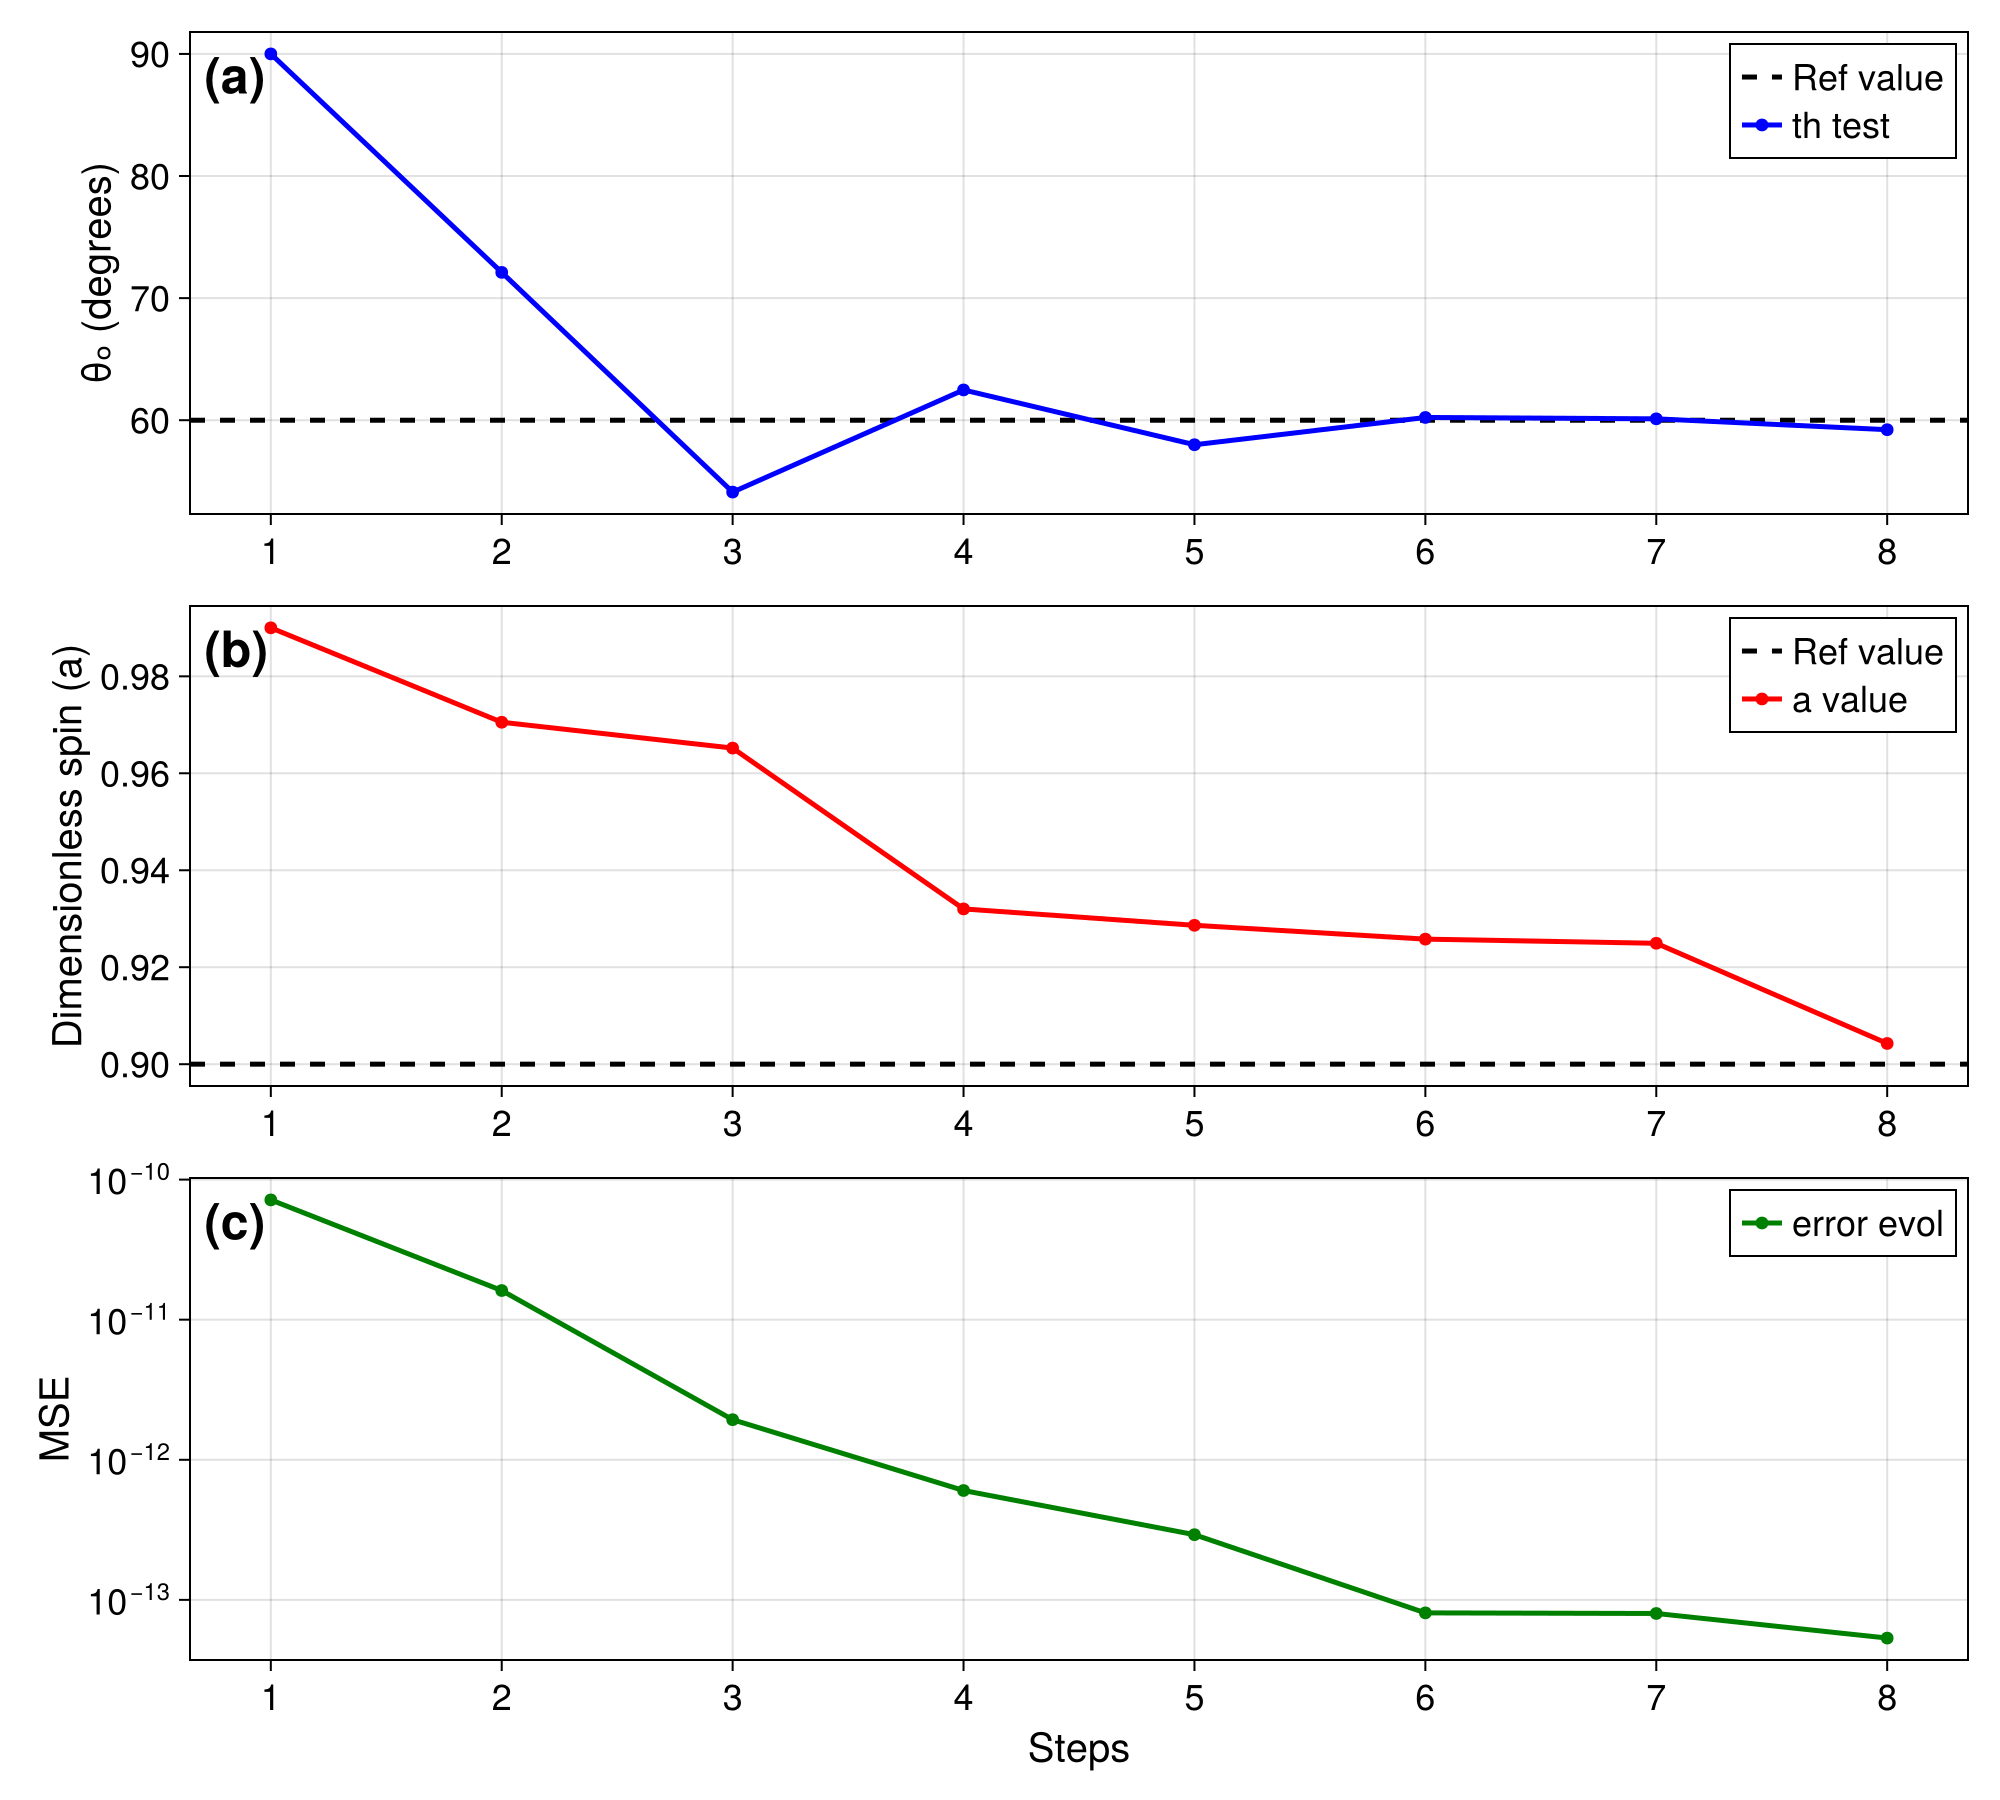

In [52]:
using CairoMakie

fig = Figure(size = (1000, 900))
xticks = 0:9  # Custom x-axis ticks

# (a) Plot θₒ
ax1 = Axis(fig[1, 1], 
    ylabel = "θₒ (degrees)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax1, 60, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax1, 1:length(ths), ths, color = :blue, linewidth = 2.5, label = "th test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# (b) Plot a
ax2 = Axis(fig[2, 1], 
    ylabel = "Dimensionless spin (a)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax2, 0.9, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax2, 1:length(as), as, color = :red, linewidth = 2.5, label = "a value")
axislegend(ax2, position = :rt, labelsize = 18)
text!(ax2, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# (c) Plot Error
ax3 = Axis(fig[3, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(c)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax2, ax3)

# Display and save
#save("../imgs/noise_comparison.png", fig)
fig